## Setup and Imports

Install the necessary libraries. The dataset and requirements are fetched automagically from the Github repo and placed in the correct location.

The only thing you need to check is that you are using a Python interpreter that is supported by Tensorflow (tested with Python3.12.13)

In [19]:
import os
import warnings

print("Installing packages", end=' ')
if os.path.exists("requirements.txt"):
    print("from local file (requirements.txt)")
    %pip install -r requirements.txt > /dev/null
else:
    print("from remote file (github.com/rrikiliba/ArduinoNano33BLESoundRecognition/blob/main/training/requirements.txt)")
    %pip install $(curl -s https://raw.githubusercontent.com/rrikiliba/ArduinoNano33BLESoundRecognition/refs/heads/main/training/requirements.txt) > /dev/null
print("Done.")

# tried minimizing useless debug prints, not with much success as you will see
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import librosa, textwrap, zipfile, warnings, urllib.request, absl.logging
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# same as above
tf.get_logger().setLevel('ERROR')
absl.logging.set_verbosity(absl.logging.ERROR)

Installing packages from remote file (github.com/rrikiliba/ArduinoNano33BLESoundRecognition/blob/main/training/requirements.txt)
Done.


optional: execute the following cell to download our dataset

In [ ]:
folder_name = "dataset"
if os.path.isdir(folder_name):
    print("Dataset folder already present.")
else:
    url = "https://raw.githubusercontent.com/rrikiliba/ArduinoNano33BLESoundRecognition/refs/heads/dataset/dataset.zip"
    rub_url = "https://raw.githubusercontent.com/rrikiliba/ArduinoNano33BLESoundRecognition/refs/heads/dataset/rub.zip"
    zip_name = "dataset.zip"
    zip_name2 = "rub.zip"

    os.mkdir(folder_name)

    print(f"Downloading {zip_name}...")
    urllib.request.urlretrieve(url, zip_name)

    print(f"Extracting to {folder_name}/")
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(path=folder_name)

    # handle both cases: zipped contents, zipped folder with contents
    contents = os.listdir(folder_name)
    if len(contents) == 1 and contents[0] == folder_name:
        for item in os.listdir(f"{folder_name}/{folder_name}"):
            os.replace(f"{folder_name}/{folder_name}/{item}", f"{folder_name}/{item}")
        os.rmdir(f"{folder_name}/{folder_name}")

    choice = input("Do you want to download the dataset for rub (y/n)? ").lower()
    if choice == 'y':
        print(f"Downloading {zip_name2}...")
        urllib.request.urlretrieve(rub_url, zip_name2)

        with zipfile.ZipFile(zip_name2, 'r') as zip_ref:
            zip_ref.extractall(path="")
        os.remove(zip_name2)
    else:
        print(f"Skipping rub dataset.")

    os.remove(zip_name)

    print("Done!")

Dataset folder already present.


# Constants Definition

This cell defines important constants that are accessed throughout the pipeline.

They are simply grouped here for convenience, in case you need to quickly edit things.

In [21]:
# audio processing constants
# you should not need to modify these as long as you
# - use the same device (Arduino Nano 33 BLE)
# - find the performance acceptable
SAMPLE_RATE = 16000
FRAME_SIZE = 512
HOP_SIZE = 320
FFT_BINS = FRAME_SIZE // 2 + 1
NUM_MEL_BINS = 32
NUM_MFCC = 13
NUM_FRAMES = (SAMPLE_RATE - FRAME_SIZE) // HOP_SIZE + 1
FMIN = 100
FMAX = 4000

# folder containing the training dataset
# each class should be in a subfolder, named as the label you
# wish to assign to said class
DATA_DIR = "dataset"

# optional transformations for data augmentation
# tried with pitching as well, but it did not yield positive results at all
# i.e. clapping becomes waaay too similar to snapping
ACTIVE_AUGMENTATIONS = ['time_shift', 'noise']

# data augmentation normally works like this:
# - check which class has the most samples
# - define target number of samples as the number of samples of that class
# - augment data from samples of other classes to produce new samples
# - stop when all classes have reached the same number of samples as the most represented class
# this percentage overrides this behaviour by forcing the script to also augment
# (by this amount) the most represented class.
# this shold prevent biases introduced by only seeing synthetic data for certain classes, but haven't tested it much
PERCENT_AUGMENTATIONS = 20#%

## Feature Extraction and Data Augmentation

The first data preprocessing step involves taking the raw .wav files and performing the following:

1. Chunking & Padding: Audio is loaded at a 16kHz sample rate and sliced into 1-second chunks. If an audio file is shorter than 1 second, it pads the end with zeros to ensure uniform input size.

1. Class Balancing: The script calculates which class (e.g., clap, snap, etc.) has the most samples. It then oversamples the minority classes so the neural network doesn't become biased.

1. Data Augmentation: To generate those extra samples for balancing, it artificially creates new variations by injecting random Gaussian noise (add_noise) or rolling the audio slightly forward/backward in time (time_shift). This is also done to a small number of samples from the most represented class.

1. Standardization: Right before feeding the data to the neural network, a StandardScaler adjusts the extracted features so they have a mean of 0 and a variance of 1. This prevents larger numerical values from overwhelming the network.

Then, for actual feature extraction:

1. Framing & Windowing: The 1-second chunk is split into small overlapping frames (512 samples each, jumping by 320). A Hamming window is applied to smooth out the edges of these frames.

1. Spectrum: A Fast Fourier Transform (FFT) converts the time-domain audio into frequency power.

1. Mel Filters: The frequencies are grouped into 32 "Mel bins" (between 20Hz and 4000Hz), which spaces the frequencies out logarithmically to mimic human hearing.

1. Log & DCT: It takes the logarithm of these energies and applies a Discrete Cosine Transform (DCT) to compress the 32 bins down to 13 distinct coefficients.

The outcome of this step is the loading in memory of the features, as well as the generation of the file `mfcc_constants.h`, which contains the constants resulting from the training, so that they can be accessed during inference. This file will be automatically placed in the [inference](inference) folder, if present. If not (for example if you're using this notebook in Colab), you will need to download it and place it in that folder yourself.


In [23]:
# dynamically load classes from `dataset` folder.
# meaning, it will
# - scan all .wav files in each folder
# - divide them in 1 second chunks
# - assign them a class based on the folder name (i.e. .wav files dataset/clap will generate samples for the clap class)
if os.path.exists(DATA_DIR) and os.path.isdir(DATA_DIR):
    CLASSES = sorted([d for d in os.listdir(DATA_DIR)
                      if os.path.isdir(os.path.join(DATA_DIR, d)) and not d.startswith('.')])
else:
    CLASSES = []

NUM_CLASSES = len(CLASSES)
print(f"Classes found: {NUM_CLASSES}. Labels are: {', '.join(['\''+CLASS+'\'' for CLASS in CLASSES])}.")

# generate mfcc constants and export them for arduino to use
window = np.hamming(FRAME_SIZE).astype(np.float32)
mel_filters = librosa.filters.mel(sr=SAMPLE_RATE, n_fft=FRAME_SIZE, n_mels=NUM_MEL_BINS, fmin=FMIN, fmax=FMAX).astype(np.float32)
mel_filters_t = mel_filters.T

dct_filters = np.zeros((NUM_MFCC, NUM_MEL_BINS), dtype=np.float32)
for i in range(NUM_MFCC):
    for j in range(NUM_MEL_BINS):
        if i == 0:
            dct_filters[i, j] = 1.0 / np.sqrt(NUM_MEL_BINS)
        else:
            dct_filters[i, j] = np.sqrt(2.0 / NUM_MEL_BINS) * np.cos(np.pi * i * (2.0 * j + 1.0) / (2.0 * NUM_MEL_BINS))
dct_filters_t = dct_filters.T

def export_c_array(name, array, filename):
    """
    formats a numpy array into a c-style syntax and appends it to a header file.
    used to hardcode matrix weights directly onto the microcontroller.
    """
    with open(filename, "a") as f:
        f.write(f"const float {name}[{array.size}] = {{\n")
        values = [f"{val:.6f}" for val in array.flatten()]
        values_str = ", ".join(values)
        f.write(textwrap.fill(values_str, width=100))
        f.write("\n};\n\n")

mfcc_path = "mfcc_constants.h"

# place it automatically in inference folder if it exists
if os.path.exists("../inference"):
    mfcc_path = f"../inference/{mfcc_path}"

# backup existing model if it exists
if os.path.exists(mfcc_path):
    os.replace(mfcc_path, f"{mfcc_path}.bak")

# write constants to header
with open(mfcc_path, "w") as f:
    f.write("#ifndef MFCC_CONSTANTS_H\n#define MFCC_CONSTANTS_H\n\n")
    f.write("// auto-generated constants from python pipeline\n")
    f.write(f"#define SAMPLE_RATE {SAMPLE_RATE}\n")
    f.write(f"#define FRAME_SIZE {FRAME_SIZE}\n")
    f.write(f"#define HOP_SIZE {HOP_SIZE}\n")
    f.write(f"#define NUM_MEL_BINS {NUM_MEL_BINS}\n")
    f.write(f"#define NUM_MFCC {NUM_MFCC}\n")
    f.write(f"#define BUFFER_SIZE {SAMPLE_RATE} // 1 second of audio\n\n")

export_c_array("hamming_window", window, mfcc_path)
export_c_array("mel_matrix", mel_filters_t, mfcc_path)
export_c_array("dct_matrix", dct_filters_t, mfcc_path)

with open(mfcc_path, "a") as f:
    f.write("#endif // MFCC_CONSTANTS_H\n")

# cmsis-matching python mfcc extractor
def compute_mfcc_cmsis_style(audio_frame):
    """
    computes mel-frequency cepstral coefficients for a single audio frame.
    mimics the mathematical steps of arm cmsis-dsp to ensure model inference
    matches exactly what the embedded device will calculate.
    """
    windowed = audio_frame * window
    spectrum = np.abs(np.fft.rfft(windowed)) ** 2
    mel_energies = np.dot(spectrum, mel_filters_t)
    log_mel = np.log(mel_energies + 1e-6)
    mfcc = np.dot(log_mel, dct_filters_t)
    return mfcc

def extract_features(audio_chunk):
    """
    slides across an audio chunk to extract mfcc features frame-by-frame.
    returns the complete feature matrix if it matches the expected number of frames.
    """
    mfccs = np.array([compute_mfcc_cmsis_style(audio_chunk[i:i+FRAME_SIZE])
                      for i in range(0, len(audio_chunk) - FRAME_SIZE + 1, HOP_SIZE)])
    if mfccs.shape[0] == NUM_FRAMES:
        return mfccs
    return None

def add_noise(audio, noise_factor=0.005):
    """
    injects random gaussian noise into the audio signal for data augmentation.
    """
    noise = np.random.randn(len(audio)).astype(np.float32)
    return audio + (noise_factor * noise)

def time_shift(audio, shift_max=SAMPLE_RATE//10):
    """
    randomly rolls the audio array forward or backward to shift it in time.
    creates variations in when the sound occurs within the 1-second window.
    """
    shift = np.random.randint(-shift_max, shift_max)
    return np.roll(audio, shift)

def get_audio_chunks(filepath):
    """
    loads a wav file, divides it into precise 1-second and
    pads with zeros if the audio is shorter than the required chunk size.
    """
    audio, _ = librosa.load(filepath, sr=SAMPLE_RATE)
    chunk_size = SAMPLE_RATE
    chunks = []

    if len(audio) < chunk_size:
        audio = np.pad(audio, (0, chunk_size - len(audio)))
        chunks.append(audio)
    else:
        for i in range(0, len(audio), chunk_size):
            chunk = audio[i:i+chunk_size]
            if len(chunk) == chunk_size:
                chunks.append(chunk)
    return chunks

# balance & augment dataset. The target number of samples is the number of samples of the class with most
raw_class_chunks = {idx: [] for idx in range(NUM_CLASSES)}

if os.path.exists(DATA_DIR):
    print(f"\nLoading data from '{DATA_DIR}'...")
    for idx, label in enumerate(CLASSES):
        folder = os.path.join(DATA_DIR, label)
        if os.path.isdir(folder):
            for file in os.listdir(folder):
                if file.endswith(".wav"):
                    filepath = os.path.join(folder, file)
                    raw_class_chunks[idx].extend(get_audio_chunks(filepath))

total_samples_found = sum(len(chunks) for chunks in raw_class_chunks.values())
X_all, y_all, groups_all = [], [], []
global_window_id = 0

if total_samples_found > 0:
    max_samples = round(max(len(chunks) for chunks in raw_class_chunks.values()) * (1+(PERCENT_AUGMENTATIONS/100)))
    print(f"Balancing dataset... Target size per class: {max_samples} samples")

    for idx, label in enumerate(CLASSES):
        base_chunks = raw_class_chunks[idx]
        original_count = len(base_chunks)
        if original_count == 0: continue

        base_chunk_ids = []
        for chunk in base_chunks:
            mfccs = extract_features(chunk)
            if mfccs is not None:
                X_all.append(mfccs)
                y_all.append(idx)
                groups_all.append(global_window_id)
            base_chunk_ids.append(global_window_id)
            global_window_id += 1

        augmentations_needed = max_samples - original_count
        print(f"Class '{label}' has {original_count} samples. Generating {augmentations_needed}...", end=' ')
        for _ in range(augmentations_needed):
            base_idx = np.random.randint(0, original_count)
            base_chunk = base_chunks[base_idx]
            base_id = base_chunk_ids[base_idx]

            aug_chunk = base_chunk.copy()
            if 'time_shift' in ACTIVE_AUGMENTATIONS and np.random.rand() > 0.5:
                aug_chunk = time_shift(aug_chunk)
            if 'noise' in ACTIVE_AUGMENTATIONS and np.random.rand() > 0.5:
                aug_chunk = add_noise(aug_chunk)

            mfccs = extract_features(aug_chunk)
            if mfccs is not None:
                X_all.append(mfccs)
                y_all.append(idx)
                groups_all.append(base_id)
        print("Done.")


    print("Splitting dataset:", end=' ')
    X_all, y_all, groups_all = np.array(X_all), np.array(y_all), np.array(groups_all)

    # use groupshufflesplit to prevent augmented versions of the same sound
    # from leaking across both the training and testing sets.
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    print(f"Train set: {len(y_train)} samples, Test set: {len(y_test)} samples")

Classes found: 4. Labels are: 'clap', 'silence', 'snap', 'tap'.

Loading data from 'dataset'...
Balancing dataset... Target size per class: 215 samples
Class 'clap' has 138 samples. Generating 77... Done.
Class 'silence' has 179 samples. Generating 36... Done.
Class 'snap' has 154 samples. Generating 61... Done.
Class 'tap' has 60 samples. Generating 155... Done.
Splitting dataset: Train set: 675 samples, Test set: 185 samples


# Train the Model

The following cell will define and train a convolutional neural network with the data that was previously loaded or generated.

The major challenge was finding an architecture that could distinguish the more similar sounding classes, like snap and clap, and we settled for 2 convolutional layers with 2 global pooling steps, one with max pooling and the other with average pooling.

You can check the step by step explaination below for more details.

In [24]:

# standard scaler implementation
X_train_flat = X_train.reshape(-1, NUM_MFCC)
X_test_flat = X_test.reshape(-1, NUM_MFCC)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

X_train = X_train_scaled.reshape(X_train.shape[0], NUM_FRAMES, NUM_MFCC, 1)
X_test = X_test_scaled.reshape(X_test.shape[0], NUM_FRAMES, NUM_MFCC, 1)

# improved dual-pooling cnn architecture
# we use the functional api here to branch the network for max and avg pooling
inputs = layers.Input(shape=(NUM_FRAMES, NUM_MFCC, 1))

# taller (5,3) time kernel to capture the shape of the sound envelope
x = layers.Conv2D(16, (5, 3), activation='relu', padding='same')(inputs)

# pool frequency by 2, but leave time untouched (1).
# this gives the model maximum temporal resolution to see the clap's decay.
x = layers.MaxPooling2D((2, 1))(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)

# the following was basically made entirely to distinguish snaps from claps:
# snaps are extremely sharp. claps are loud but have a longer reverberating "tail".

# max pooling grabs the sharpest peak (they both look identical in this layer).
max_pool = layers.GlobalMaxPooling2D()(x)

# average pooling measures the sustained energy over the entire second.
# claps have significantly higher average energy over time than snaps (due to what we called the tail).
avg_pool = layers.GlobalAveragePooling2D()(x)

# by combining them, the dense layer learns to compare peak vs sustain.
merged = layers.Concatenate()([max_pool, avg_pool])

x = layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(merged)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)

print("\nTraining Convolutional Neural Network...")
history = model.fit(
    X_train, y_train, epochs=100, validation_data=(X_test, y_test),
    batch_size=16, callbacks=[early_stopping], verbose=1
)

best_epoch = early_stopping.best_epoch


Training Convolutional Neural Network...
Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4074 - loss: 1.3172 - val_accuracy: 0.7297 - val_loss: 1.1218
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5867 - loss: 1.0735 - val_accuracy: 0.7730 - val_loss: 0.9175
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7244 - loss: 0.8725 - val_accuracy: 0.8270 - val_loss: 0.7177
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8089 - loss: 0.6696 - val_accuracy: 0.8324 - val_loss: 0.6219
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8504 - loss: 0.5596 - val_accuracy: 0.8432 - val_loss: 0.5403
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8874 - loss: 0.4385 - val_accuracy: 0.8919 - val_loss: 0.3625
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8933 - loss: 0.3747 - val_accuracy: 0.8973 - val_loss: 0.3538
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy

# Evaluate the Model

We separated this step just to make the output more readable.

You will see various accuracy metrics for the model just trained.

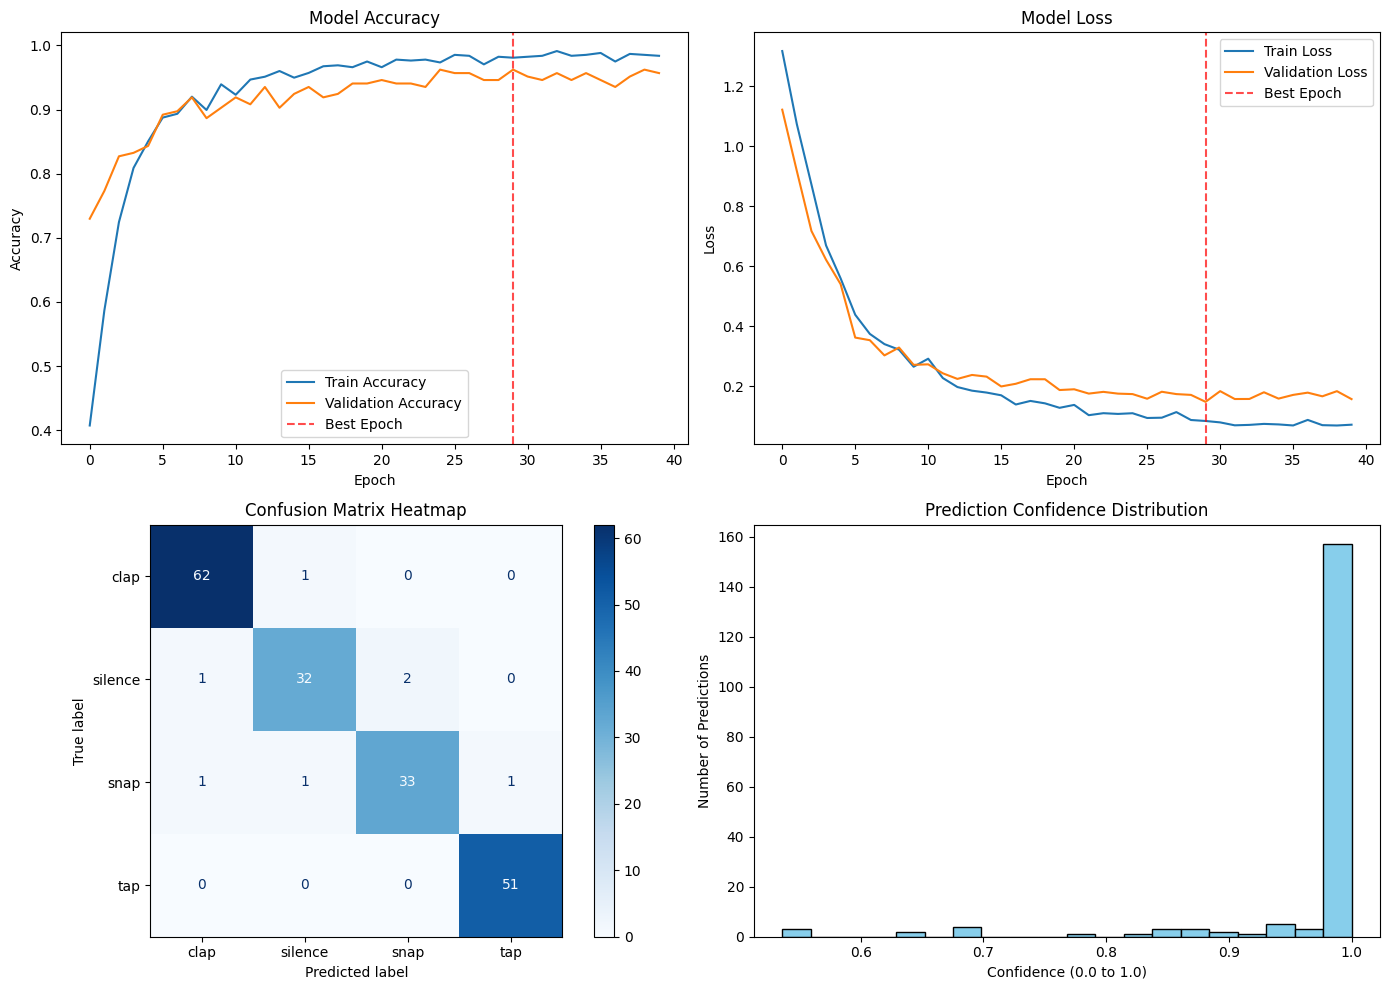


               precision    recall  f1-score   support

        clap       0.97      0.98      0.98        63
     silence       0.94      0.91      0.93        35
        snap       0.94      0.92      0.93        36
         tap       0.98      1.00      0.99        51

    accuracy                           0.96       185
   macro avg       0.96      0.95      0.96       185
weighted avg       0.96      0.96      0.96       185



In [25]:
raw_probabilities = model.predict(X_test, verbose=0)
predictions = np.argmax(raw_probabilities, axis=1)

# Create a 2x2 grid for plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Plot the Learning Curves - Accuracy (Top Left)
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 0].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label='Best Epoch')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# 2. Plot the Learning Curves - Loss (Top Right)
axes[0, 1].plot(history.history['loss'], label='Train Loss')
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label='Best Epoch')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# 3. Graphical Confusion Matrix (Bottom Left)
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=CLASSES,
    cmap=plt.cm.Blues,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Confusion Matrix Heatmap")

# 4. Confidence Distribution (Bottom Right)
max_confidences = np.max(raw_probabilities, axis=1)
axes[1, 1].hist(max_confidences, bins=20, edgecolor='black', color='skyblue')
axes[1, 1].set_title("Prediction Confidence Distribution")
axes[1, 1].set_xlabel("Confidence (0.0 to 1.0)")
axes[1, 1].set_ylabel("Number of Predictions")

plt.tight_layout()
plt.show()

print("\n", classification_report(y_test, predictions, target_names=CLASSES))

# tflite_size_kb = len(tflite_model) / 1024.0
# print(f"\nModel Size: {tflite_size_kb:.2f} KB")

# Export the Model

The model will be exported both as a `.tflite` file and as a C++/Arduino compatible header file (`.h`). If you are running this this code in vscode, it will automatically place it in the [inference](../inference) folder, if not, make sure to download and transfer it yourself, before attempting to load the Arduino sketch to the board.

In [26]:
def representative_dataset():
    """
    yields a subset of training data for the tflite converter.
    used to accurately calibrate integer boundaries during int8 quantization.
    """
    for i in range(min(100, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

model_path = "model.tflite"

# backup existing model if it exists
if os.path.exists(model_path):
    os.replace(model_path, f"{model_path}.bak")

with open(model_path, "wb") as f:
    f.write(tflite_model)

hex_array_str = ', '.join([f'0x{b:02x}' for b in tflite_model])
wrapped_hex_array = textwrap.fill(hex_array_str, width=100)
labels_str = ', '.join([f'"{name}"' for name in CLASSES])

scaler_means_str = ', '.join([f"{val:.6f}" for val in scaler.mean_])
scaler_scales_str = ', '.join([f"{val:.6f}" for val in scaler.scale_])
wrapped_means = textwrap.fill(scaler_means_str, width=100)
wrapped_scales = textwrap.fill(scaler_scales_str, width=100)

c_code = f"""// automatically generated model and metadata
#ifndef MODEL_H
#define MODEL_H

const int NUM_CLASSES = {NUM_CLASSES};
const char* const GESTURE_LABELS[] = {{{labels_str}}};

// standard scaler values to prevent quantization clipping
const float scaler_mean[{NUM_MFCC}] = {{
{wrapped_means}
}};

const float scaler_scale[{NUM_MFCC}] = {{
{wrapped_scales}
}};

const unsigned int model_tflite_len = {len(tflite_model)};
alignas(8) const unsigned char model_tflite[] = {{
{wrapped_hex_array}
}};

#endif // MODEL_H
"""

model_path = "model.h"

# place it automatically in inference folder if it exists
if os.path.exists("../inference"):
    model_path = f"../inference/{model_path}"

# backup existing model if it exists
if os.path.exists(model_path):
    os.replace(model_path, f"{model_path}.bak")

with open(model_path, "w") as f:
    f.write(c_code)

print("Exported improved model.h and model.tflite successfully!")

Saved artifact at '/tmp/tmpnnsohjs4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49, 13, 1), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135692693976272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135692693977808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135692693971280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135692693964944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135692693970320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135692693974736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135692693966288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135692693971088: TensorSpec(shape=(), dtype=tf.resource, name=None)
Exported improved model.h and model.tflite successfully!
